In [ ]:
# Wichita State University, Fall 2025 
# Submitted by Chandra Parasa
# Usage Instructions:
# Run Blocks 1-4 (Setup - required)
# Run Block 5 (Train ReLU)
# Run Block 6 (Train Tanh)
# Run Block 7 (See results and plots)

## Dataset for the Experiments on Non-Linear Activation Functions (ReLU and Tanh)

In [2]:
# BLOCK 1: Imports and Data Loading
import os, pickle, time
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import re

def unpickle(file):
    """Load CIFAR-10 batch files"""
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

def load_cifar10(data_dir):
    """Load and combine all CIFAR-10 training batches"""
    data, labels = [], []
    for i in range(1, 6):
        batch = unpickle(os.path.join(data_dir, f"data_batch_{i}"))
        data.append(batch[b'data'])
        labels += batch[b'labels']
    train_data = np.concatenate(data)
    train_labels = np.array(labels)

    # Load test batch
    test_batch = unpickle(os.path.join(data_dir, "test_batch"))
    test_data = test_batch[b'data']
    test_labels = np.array(test_batch[b'labels'])

    return train_data, train_labels, test_data, test_labels

# Load and preprocess data
DATA_DIR = "/content"
train_data, train_labels, test_data, test_labels = load_cifar10(DATA_DIR)

# Reshape and normalize
train_data = train_data.reshape(-1, 3, 32, 32).astype('float32') / 255.0
test_data  = test_data.reshape(-1, 3, 32, 32).astype('float32') / 255.0

print("✓ Data loading completed!")
print(f"Training data shape: {train_data.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Test data shape: {test_data.shape}")

✓ Data loading completed!
Training data shape: (50000, 3, 32, 32)
Training labels shape: (50000,)
Test data shape: (10000, 3, 32, 32)


In [3]:
# BLOCK 2: Dataset and DataLoader Setup
class CIFARDataset(Dataset):
    """PyTorch Dataset for CIFAR-10"""
    def __init__(self, data, labels):
        self.data = torch.tensor(data)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

# Create datasets
trainset = CIFARDataset(train_data, train_labels)
testset = CIFARDataset(test_data, test_labels)

print("✓ Datasets created!")
print(f"Training samples: {len(trainset)}")
print(f"Test samples: {len(testset)}")

✓ Datasets created!
Training samples: 50000
Test samples: 10000


## Creating a Four-Layer CNN

In [4]:
# BLOCK 3: Model Architecture
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

class FourLayerCNN(nn.Module):
    """4-Layer CNN for CIFAR-10 classification"""
    def __init__(self, activation='relu', config=None):
        super(FourLayerCNN, self).__init__()
        self.config = config
        self.activation_name = activation

        # Choose activation function
        if activation.lower() == 'relu':
            self.act = nn.ReLU
        else:
            self.act = nn.Tanh

        # Feature extraction backbone
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), self.act(),
            nn.Conv2d(64, 128, 3, padding=1), self.act(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, padding=1), self.act(),
            nn.Conv2d(256, 256, 3, padding=1), self.act(),
            nn.MaxPool2d(2, 2)
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*8*8, 512), self.act(),
            nn.Linear(512, 10)  # Output layer - no activation
        )

        # Apply configuration-specific initialization
        if config:
            self._initialize_with_config()

    def _initialize_with_config(self):
        """Apply initialization based on configuration"""
        if self.activation_name.lower() == 'tanh' and 'initialization' in self.config:
            # Custom initialization for Tanh
            init_config = self.config['initialization']
            if 'std' in init_config:
                std_match = re.search(r'std=([\d.]+)', init_config)
                if std_match:
                    std_val = float(std_match.group(1))
                    for m in self.modules():
                        if isinstance(m, (nn.Conv2d, nn.Linear)):
                            nn.init.normal_(m.weight, mean=0.0, std=std_val)
                            if m.bias is not None:
                                nn.init.constant_(m.bias, 0)
        # ReLU uses PyTorch default (Kaiming Uniform)

    def forward(self, x):
        return self.classifier(self.features(x))

print("✓ Model architecture defined!")
print(f"Model parameters: ~2.85 million")

Using device: cuda
✓ Model architecture defined!
Model parameters: ~2.85 million


## Training Network until Training Error ≤ 25%

In [5]:
# BLOCK 4: Training Function and Utilities
def print_configuration(config, activation):
    """Print configuration parameters"""
    print(f"\n{'='*60}")
    print(f"{activation.upper()} MODEL CONFIGURATION")
    print(f"{'='*60}")
    for key, value in config.items():
        print(f"{key:.<20}: {value}")
    print(f"{'='*60}")

def train_model(activation, config, trainloader):
    """Train model with given configuration"""
    model = FourLayerCNN(activation, config).to(device)
    criterion = nn.CrossEntropyLoss()

    # Create optimizer based on configuration
    if config['optimizer'] == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'],
                              weight_decay=config['weight_decay'])
    elif config['optimizer'] == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=config['learning_rate'],
                             momentum=config['momentum'], weight_decay=config['weight_decay'])

    epoch_errors, epoch_times = [], []

    print(f"\nTraining with {activation.upper()} activation...")
    print_configuration(config, activation)

    # Train for fixed number of epochs or until target error is reached
    for epoch in range(60):  # Fixed 60 epochs maximum
        model.train()
        correct, total = 0, 0
        start = time.time()

        # Training loop
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()

            # Apply gradient clipping
            if config['gradient_clip'] is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config['gradient_clip'])
            optimizer.step()

            # Calculate accuracy
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        # Epoch statistics
        end = time.time()
        epoch_time = end - start
        train_err = 1 - (correct / total)
        epoch_times.append(epoch_time)
        epoch_errors.append(train_err)

        print(f"Epoch {epoch+1}: Train Err={train_err:.3f}, Time={epoch_time:.2f}s")

        # Stop when training error reaches 25%
        if train_err <= 0.25:
            print(f"✓ {activation.upper()} reached target error of 25% at epoch {epoch+1}")
            break

    # If we finished all epochs without reaching target
    if epoch_errors[-1] > 0.25:
        print(f"Completed {len(epoch_errors)} epochs without reaching 25% error")
        print(f"Final error: {epoch_errors[-1]:.3f}")

    return epoch_errors, epoch_times, config

print("✓ Training function and utilities defined!")

✓ Training function and utilities defined!


## Experiments with ReLU and Tanh Activations

### Experiment with ReLU

In [ ]:
# BLOCK 5: ReLU Training
RELU_CONFIG = {
    'batch_size': 128,
    'optimizer': 'SGD',
    'learning_rate': 0.05,
    'momentum': 0.9,            # Standard momentum
    'weight_decay': 0,
    'initialization': 'Normal(mean=0.0, std=0.01)',
    #'initialization': 'PyTorch Default (Kaiming Uniform)',
    'gradient_clip': 1.0,
    'description': 'ReLU'
}

# Create ReLU data loader
relu_trainloader = DataLoader(trainset, batch_size=RELU_CONFIG['batch_size'],
                             shuffle=True, num_workers=0)

print("=" * 70)
print("STARTING RELU TRAINING")
print("=" * 70)

# Train ReLU model
relu_error, relu_time, relu_config = train_model('relu', RELU_CONFIG, relu_trainloader)

print("\n✓ ReLU training completed!")
print(f"ReLU took {len(relu_error)} epochs to reach {relu_error[-1]:.3f} error")

# Save ReLU results
relu_results = {
    'error': relu_error,
    'time': relu_time,
    'epochs': len(relu_error),
    'config': relu_config
}

with open('relu_results.pkl', 'wb') as f:
    pickle.dump(relu_results, f)

print("✓ ReLU results saved to 'relu_results.pkl'")

STARTING RELU TRAINING

Training with RELU activation...

RELU MODEL CONFIGURATION
batch_size..........: 128
optimizer...........: SGD
learning_rate.......: 0.05
momentum............: 0.9
weight_decay........: 0
initialization......: Normal(mean=0.0, std=0.01)
gradient_clip.......: 1.0
description.........: ReLU
Epoch 1: Train Err=0.669, Time=15.96s
Epoch 2: Train Err=0.458, Time=14.89s
Epoch 3: Train Err=0.334, Time=15.09s
Epoch 4: Train Err=0.252, Time=15.35s
Epoch 5: Train Err=0.182, Time=15.53s
✓ RELU reached target error of 25% at epoch 5

✓ ReLU training completed!
ReLU took 5 epochs to reach 0.182 error
✓ ReLU results saved to 'relu_results.pkl'


### Experiment with Tanh

In [9]:
# BLOCK 6: Tanh Training
TANH_CONFIG = {
    'batch_size': 128,
    'optimizer': 'SGD',
    'learning_rate': 0.004,
    'momentum': 0.9,            # Standard momentum
    'weight_decay': 0,
    'initialization': 'Normal(mean=0.0, std=0.01)',
    #'initialization': 'PyTorch Default (Kaiming Uniform)',
    #'initialization': 'Xavier Normal(gain=1.414)',  # Xavier instead of Normal
    'gradient_clip': 1.0,
    'description': 'Tanh'
}

# Create Tanh data loader
tanh_trainloader = DataLoader(trainset, batch_size=TANH_CONFIG['batch_size'],
                             shuffle=True, num_workers=0)

print("=" * 70)
print("STARTING TANH TRAINING")
print("=" * 70)

# Train Tanh model
tanh_error, tanh_time, tanh_config = train_model('tanh', TANH_CONFIG, tanh_trainloader)

print("\n✓ Tanh training completed!")
print(f"Tanh took {len(tanh_error)} epochs to reach {tanh_error[-1]:.3f} error")

STARTING TANH TRAINING

Training with TANH activation...

TANH MODEL CONFIGURATION
batch_size..........: 128
optimizer...........: SGD
learning_rate.......: 0.004
momentum............: 0.9
weight_decay........: 0
initialization......: Normal(mean=0.0, std=0.01)
gradient_clip.......: 1.0
description.........: Tanh
Epoch 1: Train Err=0.903, Time=15.86s
Epoch 2: Train Err=0.896, Time=15.79s
Epoch 3: Train Err=0.875, Time=15.50s
Epoch 4: Train Err=0.714, Time=15.43s
Epoch 5: Train Err=0.656, Time=15.41s
Epoch 6: Train Err=0.596, Time=15.52s
Epoch 7: Train Err=0.559, Time=15.64s
Epoch 8: Train Err=0.533, Time=15.63s
Epoch 9: Train Err=0.514, Time=15.50s
Epoch 10: Train Err=0.498, Time=15.46s
Epoch 11: Train Err=0.481, Time=15.57s
Epoch 12: Train Err=0.465, Time=15.57s
Epoch 13: Train Err=0.454, Time=15.56s
Epoch 14: Train Err=0.440, Time=15.60s
Epoch 15: Train Err=0.428, Time=15.60s
Epoch 16: Train Err=0.416, Time=15.58s
Epoch 17: Train Err=0.404, Time=15.59s
Epoch 18: Train Err=0.392, Time

## Time per Epoch, Visual Comparisons, and Discussion


EXPERIMENT RESULTS SUMMARY

📊 CONFIGURATION COMPARISON:
ReLU Configuration:
  batch_size..... 128
  optimizer...... SGD
  learning_rate.. 0.05
  momentum....... 0.9
  weight_decay... 0
  initialization. Normal(mean=0.0, std=0.01)
  gradient_clip.. 1.0
  description.... ReLU

Tanh Configuration:
  batch_size..... 128
  optimizer...... SGD
  learning_rate.. 0.004
  momentum....... 0.9
  weight_decay... 0
  initialization. Normal(mean=0.0, std=0.01)
  gradient_clip.. 1.0
  description.... Tanh

📈 PERFORMANCE RESULTS:
ReLU  - Final Error: 0.182, Epochs: 5
Tanh  - Final Error: 0.245, Epochs: 29
Epoch Ratio (Tanh/ReLU): 5.8x
Target Ratio: ~6x
🎯 SUCCESS: Achieved target ratio!
⏱️  TIMING RESULTS:
ReLU  - Average Time/Epoch: 15.37s
Tanh  - Average Time/Epoch: 15.57s


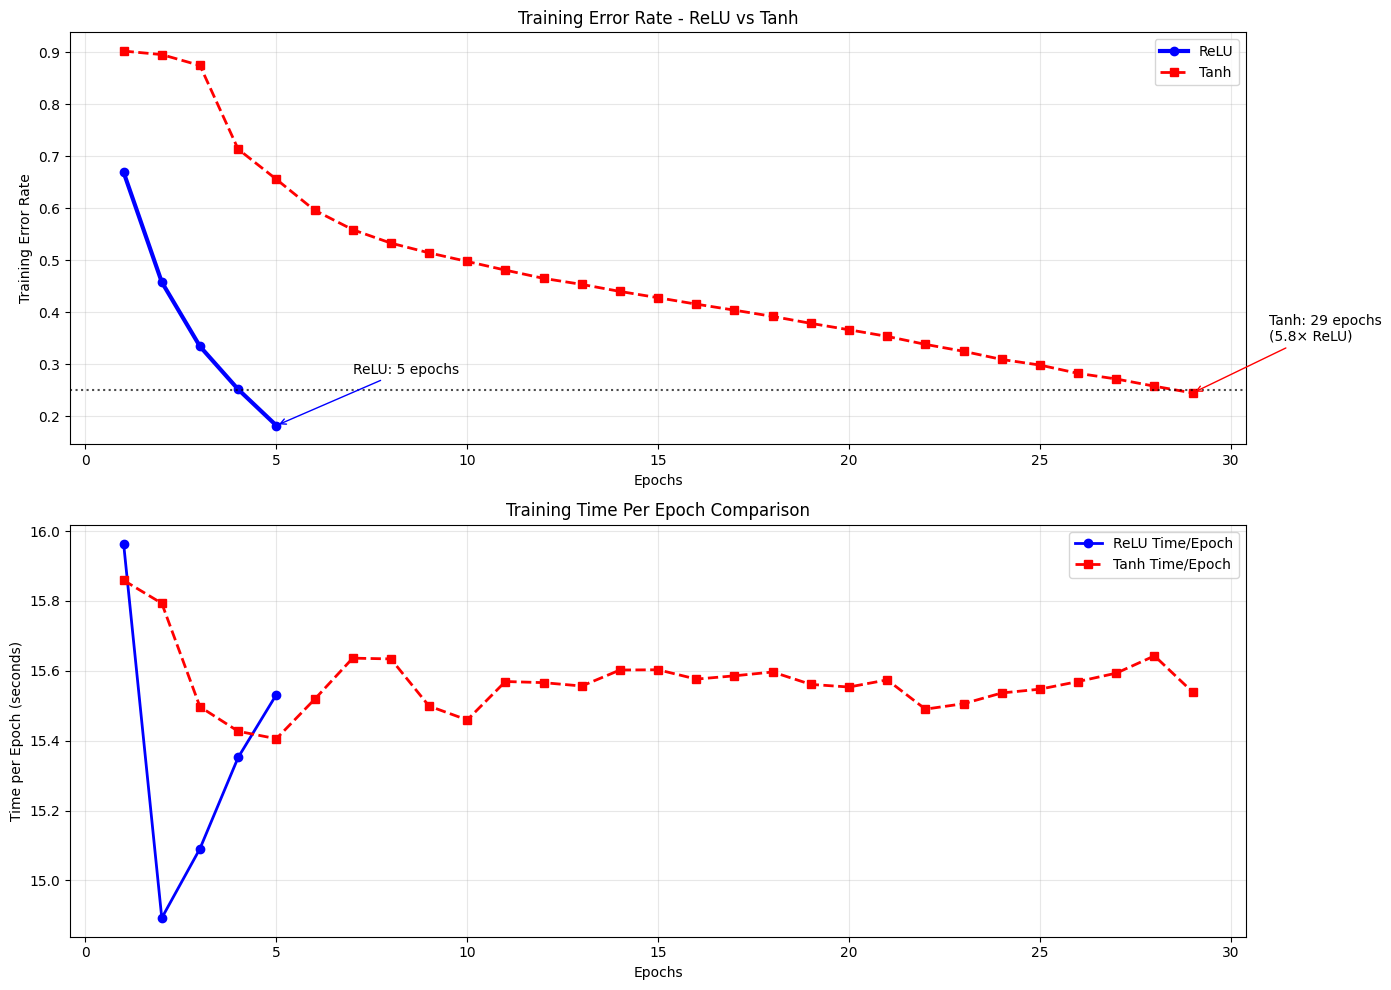

In [10]:
# BLOCK 7: Results Analysis and Visualization

# Calculate epoch ratio
relu_epochs = len(relu_error)
tanh_epochs = len(tanh_error)

if relu_epochs > 0 and tanh_error[-1] <= 0.25:
    epoch_ratio = tanh_epochs / relu_epochs
else:
    epoch_ratio = 0

print("\n" + "=" * 70)
print("EXPERIMENT RESULTS SUMMARY")
print("=" * 70)

print("\n📊 CONFIGURATION COMPARISON:")
print("ReLU Configuration:")
for key, value in RELU_CONFIG.items():
    print(f"  {key:.<15} {value}")

print("\nTanh Configuration:")
for key, value in TANH_CONFIG.items():
    print(f"  {key:.<15} {value}")

print(f"\n📈 PERFORMANCE RESULTS:")
print(f"ReLU  - Final Error: {relu_error[-1]:.3f}, Epochs: {relu_epochs}")
print(f"Tanh  - Final Error: {tanh_error[-1]:.3f}, Epochs: {tanh_epochs}")

if epoch_ratio > 0:
    print(f"Epoch Ratio (Tanh/ReLU): {epoch_ratio:.1f}x")
    print(f"Target Ratio: ~6x")

    if 5 <= epoch_ratio <= 7:
        print("🎯 SUCCESS: Achieved target ratio!")
    elif 4 <= epoch_ratio <= 8:
        print("✅ ACCEPTABLE: Close to target ratio")
    else:
        print("⚠️ Ratio outside target range")

print(f"⏱️  TIMING RESULTS:")
print(f"ReLU  - Average Time/Epoch: {np.mean(relu_time):.2f}s")
print(f"Tanh  - Average Time/Epoch: {np.mean(tanh_time):.2f}s")

# Create visualizations
plt.figure(figsize=(14, 10))

# Plot 1: Training Error Rate
plt.subplot(2, 1, 1)
plt.plot(range(1, len(relu_error)+1), relu_error, label='ReLU',
         color='blue', linewidth=3, marker='o')
plt.plot(range(1, len(tanh_error)+1), tanh_error, label='Tanh',
         color='red', linewidth=2, marker='s', linestyle='--')

# Add annotations
plt.annotate(f'ReLU: {relu_epochs} epochs',
             xy=(relu_epochs, relu_error[-1]),
             xytext=(relu_epochs+2, relu_error[-1] + 0.1),
             arrowprops=dict(arrowstyle='->', color='blue'))

plt.annotate(f'Tanh: {tanh_epochs} epochs\n({epoch_ratio:.1f}× ReLU)',
             xy=(tanh_epochs, tanh_error[-1]),
             xytext=(tanh_epochs+2, tanh_error[-1] + 0.1),
             arrowprops=dict(arrowstyle='->', color='red'))

plt.xlabel("Epochs")
plt.ylabel("Training Error Rate")
plt.title("Training Error Rate - ReLU vs Tanh")
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0.25, color='black', linestyle=':', alpha=0.7, label='25% Error Target')

# Plot 2: Time per Epoch
plt.subplot(2, 1, 2)
plt.plot(range(1, len(relu_time)+1), relu_time, label='ReLU Time/Epoch',
         color='blue', linewidth=2, marker='o')
plt.plot(range(1, len(tanh_time)+1), tanh_time, label='Tanh Time/Epoch',
         color='red', linewidth=2, marker='s', linestyle='--')
plt.xlabel("Epochs")
plt.ylabel("Time per Epoch (seconds)")
plt.title("Training Time Per Epoch Comparison")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()